In [39]:
%matplotlib inline

**ToDo**
- plot source time function in x and y x 
- in space time (waterfall plots): plot x and y 
- plot pccolormesh plots in imshow to verify x
- plot wiggles for plots x
- write summary of crack types
- have supersjear simulation: check if it's different from sub-rayleigh (should be!!!!) x
- make domain larger and cut simulation off to get rid of imperfect abc effects x


In [40]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_fault_zone_czm_adjusted_time_domain_supershear" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [41]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [42]:
# Layered model setup: three layers ordered as snow, weak layer (wl), air.

x_min, x_max = 0.0, 400.0

# Geometry (high y = top of domain ):
slab_bottom = 0.0
slab_thickness = 1.0
wl_thickness = 0.01 # doesnt matter right now because vp, vs and rho are the same as snow 
domain_top = 3.0

slab_top = slab_bottom + slab_thickness # snow-wl interface
wl_bottom = slab_top
wl_top = wl_bottom + wl_thickness #wl-air interface
air_top = domain_top

# Boundaries from top to bottom -> 3 layers.
layers_x = [
    np.array([x_min, x_max]),# top boundary
    np.array([x_min, x_max]),# air-wl interface
    np.array([x_min, x_max]),# wl-snow interface
    np.array([x_min, x_max]),# bottom boundary
]
layers_y = [
    np.array([air_top, air_top]),
    np.array([wl_top, wl_top]),
    np.array([wl_bottom, wl_bottom]),
    np.array([slab_bottom, slab_bottom]),
]

# Material parameters by region index [snow air].
vp = np.array([300.0,  300, 332.0])
vs = np.array([150.0, 150.0, 0.0])
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

max_frequency = 50.0
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
# print("Three-layer mesh built.")
# print(f"  Snow layer: y = [{slab_bottom:.2f}, {slab_top:.2f}] m, vs=150 m/s")
# print(f"  Weak layer: y = [{wl_bottom:.2f}, {wl_top:.2f}] m, vs=60 m/s")
# print(f"  Air layer:  y = [{wl_top:.2f}, {air_top:.2f}] m, vs=0 m/s")

In [43]:
def cohesive_stress_profile(xi, softening="linear"):

    """
    Normalized cohesive traction t/t0 as a function of normalized opening xi.
    xi = delta / delta_c in [0, 1] in Mahajan & Joshi (2008): 
    """

    xi = np.atleast_1d(np.asarray(xi, dtype=float))

    sigma = np.zeros_like(xi)

    if softening == "linear":

        sigma = np.maximum(0.0, 1.0 - xi)

    elif softening == "exponential":

        sigma = np.exp(-xi * np.log(2.0))

    elif softening == "bilinear":

        xi1 = 0.2

        s1 = 0.4

        for i, x in enumerate(xi):

            if x <= 0.0:

                sigma[i] = 1.0

            elif x <= xi1:

                sigma[i] = 1.0 - (1.0 - s1) / xi1 * x

            elif x <= 1.0:

                sigma[i] = s1 * (1.0 - x) / (1.0 - xi1)

            else:

                sigma[i] = 0.0

    else:

        raise ValueError(f"Unsupported softening law: {softening}")



    return sigma if len(sigma) > 1 else float(sigma[0])





def _isotropic_E_from_vp_vs_rho(vp_val, vs_val, rho_val):

    """Convert (vp, vs, rho) to Young's modulus using isotropic elasticity."""

    mu = rho_val * vs_val**2

    lam = rho_val * (vp_val**2 - 2.0 * vs_val**2)

    if (lam + mu) <= 0.0:

        raise ValueError("Invalid elastic parameters: lambda + mu must be positive.")

    E = mu * (3.0 * lam + 2.0 * mu) / (lam + mu)

    return E, mu




def mahajan_joshi_slip_distribution(

    x_positions,

    crack_tip_x,

    l_cz,

    delta_c,

    softening="linear",

):

    """
    Slip profile behind a propagating interfacial crack tip using a cohesive zone.

    The model follows Mahajan & Joshi (2008) structure:

    - interfacial crack in mode II with compression,

    - damage regularized by a cohesive zone.

    """

    slips = np.zeros(len(x_positions))



    ref_xi = np.linspace(0.0, 1.0, 300)

    ref_norm = np.trapz(1.0 - cohesive_stress_profile(ref_xi, softening), ref_xi)

    ref_norm = max(ref_norm, 1e-12)



    for i, x in enumerate(x_positions):

        dist_behind_tip = crack_tip_x - x

        if dist_behind_tip < 0.0:

            slips[i] = 0.0

        elif dist_behind_tip <= l_cz:

            xi = 1.0 - dist_behind_tip / l_cz

            xi_arr = np.linspace(0.0, xi, 300)

            sigma_arr = cohesive_stress_profile(xi_arr, softening)

            slips[i] = delta_c * np.trapz(1.0 - sigma_arr, xi_arr) / ref_norm

        else:

            slips[i] = delta_c



    return slips


def compute_mahajan_joshi_parameters(

    sigma_t,

    tau_s,

    G_Ic,

    G_IIc,

    vp_slab,

    vs_slab,

    rho_slab,

    vp_weak,

    vs_weak,

    rho_weak,

    slab_thickness,

    mode_mix=0.7,

):

    """
    Mahajan & Joshi (2008)-style interface model inputs.

    Required interface properties in the paper:

    - normal fracture energy G_Ic,

    - shear fracture energy G_IIc,

    - tensile strength sigma_t,

    - shear strength tau_s.

    Returns cohesive separations and a practical rupture-speed estimate constrained

    to the 50-300 m/s range reported in the paper's abstract.

    """

    if not (0.0 <= mode_mix <= 1.0):

        raise ValueError(f"mode_mix must be in [0, 1], got {mode_mix}")



    E_slab, mu_slab = _isotropic_E_from_vp_vs_rho(vp_slab, vs_slab, rho_slab)

    E_weak, mu_weak = _isotropic_E_from_vp_vs_rho(vp_weak, vs_weak, rho_weak)


    # Effective modulus of the bi-material interface (harmonic mean).

    E_eff = 2.0 * E_slab * E_weak / (E_slab + E_weak)



    # Critical separations for linear traction-separation laws.

    delta_n_c = 2.0 * G_Ic / sigma_t

    delta_s_c = 2.0 * G_IIc / tau_s

    delta_c = np.sqrt((1.0 - mode_mix) * delta_n_c**2 + mode_mix * delta_s_c**2)



    # Cohesive/process-zone scale with shear-mode control for interfacial mode-II cracks.

    l_ch = E_eff * G_IIc / max(tau_s**2, 1e-12)

    l_cz = np.pi / 8.0 * l_ch



    # Practical rupture speed estimate, clipped to reported range.

    vs_ref = min(vs_slab, vs_weak)

    stiffness_scale = np.clip(np.sqrt(E_eff / 1.0e6), 0.5, 2.5)

    thickness_scale = np.clip(np.sqrt(max(slab_thickness, 0.1)), 0.5, 2.0)

    rupture_speed_raw = vs_ref * (0.35 + 0.22 * stiffness_scale + 0.10 * thickness_scale) # rupture speed is a weighted fraction of the shear wave speed of the slowert layer, with adjustments for interface stiffness and slab thickness as in the paperv 

    #rupture_speed = float(np.clip(rupture_speed_raw, 50.0, 300.0)) # from paper
    #rupture_speed = float(np.clip(rupture_speed_raw, 0.5 * vs_ref, 0.90 * vs_ref)) # sub-rayleih: lower bounds are from paper, upper bound is 0.9 of the s-wave speed 
    rupture_speed = float(np.clip(rupture_speed_raw,  vs_ref, 10 * vs_ref)) # supershear: lower bounds is shear wave speed, upper bound is vsx10

    rise_time = l_cz / rupture_speed



    print("Mahajan-Joshi interface model parameters:")

    print(f"  sigma_t (normal strength): {sigma_t:.1f} Pa")

    print(f"  tau_s   (shear strength):  {tau_s:.1f} Pa")

    print(f"  G_Ic (normal fracture energy): {G_Ic:.3f} J/m^2")

    print(f"  G_IIc (shear fracture energy): {G_IIc:.3f} J/m^2")

    print(f"  E_eff: {E_eff:.0f} Pa")

    print(f"  delta_n_c: {delta_n_c*1000:.3f} mm")

    print(f"  delta_s_c: {delta_s_c*1000:.3f} mm")

    print(f"  effective delta_c: {delta_c*1000:.3f} mm")

    print(f"  process zone length l_cz: {l_cz:.3f} m")

    print(f"  rupture speed: {rupture_speed:.1f} m/s")

    print(f"  rise time: {rise_time*1000:.2f} ms")



    return {

        "sigma_t": sigma_t,

        "tau_s": tau_s,

        "G_Ic": G_Ic,

        "G_IIc": G_IIc,

        "mode_mix": mode_mix,

        "delta_n_c": delta_n_c,

        "delta_s_c": delta_s_c,

        "delta_c": delta_c,

        "l_ch": l_ch,

        "l_cz": l_cz,

        "rupture_speed": rupture_speed,

        "rise_time": rise_time,

        "E_eff": E_eff,

        "mu_slab": mu_slab,

        "mu_weak": mu_weak,

    }



# model inputs, Values from lab experiments

sigma_t = 1200.0 # Pa, tensile interface strength

tau_s = 1000.0 # Pa, shear interface strength

G_Ic = 0.35  # J/m^2, normal fracture energy

G_IIc = 0.50 # J/m^2, shear fracture energy

mode_mix = 0.7 # 0: opening-dominant, 1: shear-dominant (mode I vs mode II)



czm = compute_mahajan_joshi_parameters(

    sigma_t=sigma_t,

    tau_s=tau_s,

    G_Ic=G_Ic,

    G_IIc=G_IIc,

    vp_slab=vp[0],

    vs_slab=vs[0],

    rho_slab=rho[0],

    vp_weak=vp[1],

    vs_weak=vs[1],

    rho_weak=rho[1],

    slab_thickness=slab_thickness,

    mode_mix=mode_mix,

)



# Use model-derived rupture speed for downstream source timing.

rupture_speed = czm["rupture_speed"]


Mahajan-Joshi interface model parameters:
  sigma_t (normal strength): 1200.0 Pa
  tau_s   (shear strength):  1000.0 Pa
  G_Ic (normal fracture energy): 0.350 J/m^2
  G_IIc (shear fracture energy): 0.500 J/m^2
  E_eff: 10800000 Pa
  delta_n_c: 0.583 mm
  delta_s_c: 1.000 mm
  effective delta_c: 0.896 mm
  process zone length l_cz: 2.121 m
  rupture speed: 150.0 m/s
  rise time: 14.14 ms


In [44]:
# # Writing standard rupture format file: based on https://www.mondaic.com/case-studies/accurate-fault-planes-in-earthquake-ground-motion-modeling

# def write_snow_crack_srf(
#     filepath,
#     crack_x_start=30.0,
#     crack_x_end=270.0,
#     crack_y=wl_bottom + wl_thickness / 2.0, # crack is in the mdidle of weak layer
#     n_subfaults=120,
#     rupture_speed=125.0,  # m/s - sub-Rayleigh (vs_weak=60, vs_slab=150)
#     rise_time=0.02, # second s duration of slip at each subfault
#     total_slip=0.01, # m : max slip (10 mm), realistic for PST
#     mode_mix=1,# fraction of shear (Mode II) vs opening (Mode I): if this is 1.0, it's pure shear; if 0.0, it's pure openingh 
#     f0=10.0, # Ricker center frequency
# ):
#     """
#     Write an SRF-like ASCII file for a 2D horizontal snow crack.
    
#     In 2D Cartesian Salvus, we approximate the SRF concept by generating
#     the subfault parameters analytically and writing them in a format that
#     maps to MomentTensorPoint2D sources with per-subfault STFs.
    
#     The function returns the list of (x, y, delay, mxx, myy, mxy, rise_time)
#     tuples so they can be passed directly to Salvus.
#     """
#     crack_length = crack_x_end - crack_x_start
#     dx = crack_length / (n_subfaults - 1)
#     x_positions = np.linspace(crack_x_start, crack_x_end, n_subfaults)

#     # Onset time: crack initiates at x_start, propagates at rupture_speed
#     onset_times = (x_positions - crack_x_start) / rupture_speed

#     # Slip distribution: elliptical (Kostrov- like), tapered at tips
#     xi = (x_positions - crack_x_start) / crack_length  # 0 to 1
#     slip_distribution = total_slip * np.sqrt(np.maximum(0, xi * (1 - xi)) * 4)

#     # Moment tensor components (2D plane strain):
#     # Mode II (shear): mxy - slip along x, interface normal is y
#     # Mode I (opening): myy - normal opening
#     # Scale by shear modulus of weak layer: mu = rho * vs^2
#     mu_weak = 150.0 * 60.0**2    # ~540 kPa
#     lam_weak = rho[1] * (vp[1]**2 - 2 * vs[1]**2)  # for Mode I

#     subfaults = []
#     for i, (x_src, t_onset, slip) in enumerate(zip(x_positions, onset_times, slip_distribution)):
#         # Seismic moment per unit length (2D) = mu * slip * patch_width
#         M0 = mu_weak * slip * dx

#         # Mixed-mode moment tensor in 2D:
#         # Mode II shear: Mxy component
#         # Mode I opening: Myy component (tensile)
#         mxy = mode_mix * M0
#         myy = (1.0 - mode_mix) * M0
#         mxx = 0.0  # no out-of-plane contribution in 2D

#         subfaults.append({
#             "x": float(x_src),
#             "y": float(crack_y),
#             "onset_time": float(t_onset),
#             "rise_time": rise_time,
#             "mxx": mxx,
#             "myy": myy,
#             "mxy": mxy,
#             "slip": slip,
#         })

#     # Save to file for documentation
#     with open(filepath, "w") as f:
#         f.write("# Snow crack SRF-equivalent descriptor\n")
#         f.write(f"# crack_y={crack_y:.4f} m, rupture_speed={rupture_speed} m/s\n")
#         f.write(f"# n_subfaults={n_subfaults}, rise_time={rise_time} s\n")
#         f.write("# x_m  y_m  onset_s  rise_s  mxx  myy  mxy  slip_m\n")
#         for sf in subfaults:
#             f.write(
#                 f"{sf['x']:.4f}  {sf['y']:.4f}  {sf['onset_time']:.6f}  "
#                 f"{sf['rise_time']:.4f}  {sf['mxx']:.4f}  {sf['myy']:.4f}  "
#                 f"{sf['mxy']:.4f}  {sf['slip']:.6f}\n"
#             )

#     print(f"Wrote {len(subfaults)} subfaults to {filepath}")
#     print(f"  Crack length: {crack_length:.1f} m")
#     print(f"  Rupture duration: {onset_times[-1]:.3f} s")
#     print(f"  Peak slip: {slip_distribution.max():.4f} m")
#     print(f"  Max M0 (per subfault): {max(abs(sf['mxy'])+abs(sf['myy']) for sf in subfaults):.2e} N")
#     return subfaults


# srf_path = pathlib.Path(PROJECT_DIR) / "snow_crack.srf_equiv"
# srf_path.parent.mkdir(exist_ok=True)

# subfaults = write_snow_crack_srf(
#     srf_path,
#     crack_x_start=30.0,
#     crack_x_end=270.0,
#     crack_y=wl_bottom + wl_thickness / 2.0,
#     n_subfaults=120,
#     rupture_speed=125.0, # sub-Rayleigh, change for supershera
#     rise_time=0.02,
#     total_slip=0.01,
#     mode_mix=0.7,
#     f0=10.0,
# )

In [45]:
def write_snow_crack_srf_czm(

    filepath,

    czm_params,

    crack_x_start=30.0,

    crack_x_end=270.0,

    n_subfaults=120,

    rupture_speed=125.0,

    mode_mix=0.7,  # fraction Mode II shear vs Mode I closure

    softening="linear",

):

    """

    Write SRF-equivalent descriptor for a 2D snow crack using

    Mahajan-Joshi cohesive interface parameters.

    """

    delta_c = czm_params["delta_c"]

    l_cz = czm_params["l_cz"]

    rise_time = czm_params["rise_time"]



    crack_length = crack_x_end - crack_x_start

    dx = crack_length / (n_subfaults - 1)

    x_positions = np.linspace(crack_x_start, crack_x_end, n_subfaults)

    onset_times = (x_positions - crack_x_start) / rupture_speed



    # Slip distribution from cohesive process zone, evaluated at final tip position.

    slips = mahajan_joshi_slip_distribution(

        x_positions,

        crack_tip_x=crack_x_end,

        l_cz=l_cz,

        delta_c=delta_c,

        softening=softening,

    )



    # Shear modulus of weak layer controls mode-II moment scaling.

    mu_weak = rho[1] * vs[1] ** 2



    subfaults = []

    for x_src, t_onset, slip in zip(x_positions, onset_times, slips):

        M0 = mu_weak * slip * dx



        # Interfacial crack with shear + closure components.

        mxy = mode_mix * M0

        myy = -(1.0 - mode_mix) * M0

        mxx = 0.0



        subfaults.append(

            {

                "x": float(x_src),

                "y": float(wl_bottom + wl_thickness / 2.0),

                "onset_time": float(t_onset),

                "rise_time": float(rise_time),

                "mxx": mxx,

                "myy": myy,

                "mxy": mxy,

                "slip": float(slip),

            }

        )



    pathlib.Path(filepath).parent.mkdir(exist_ok=True)

    with open(filepath, "w") as f:

        f.write("# Snow crack SRF-equivalent: Mahajan-Joshi cohesive interface model\n")

        f.write(

            f"# delta_c={delta_c*1000:.3f} mm, l_cz={l_cz:.3f} m, "

            f"rise_time={rise_time:.5f} s\n"

        )

        f.write(

            f"# softening={softening}, mode_mix={mode_mix}, "

            f"rupture_speed={rupture_speed:.2f} m/s\n"

        )

        f.write("# x_m  y_m  onset_s  rise_s  mxx  myy  mxy  slip_m\n")

        for sf in subfaults:

            f.write(

                f"{sf['x']:.4f}  {sf['y']:.4f}  {sf['onset_time']:.6f}  "

                f"{sf['rise_time']:.6f}  {sf['mxx']:.6f}  {sf['myy']:.6f}  "

                f"{sf['mxy']:.6f}  {sf['slip']:.8f}\n"

            )



    print(f"Wrote {len(subfaults)} subfaults to {filepath}")

    print(f"  Crack length:     {crack_length:.1f} m")

    print(f"  Rupture duration: {onset_times[-1]:.3f} s")

    print(f"  Peak slip:        {slips.max()*1000:.3f} mm")

    print(f"  Process zone:     {l_cz:.3f} m")

    return subfaults





srf_path = pathlib.Path(PROJECT_DIR) / "snow_crack_mahajan_joshi.srf_equiv"

subfaults = write_snow_crack_srf_czm(

    srf_path,

    czm_params=czm,

    crack_x_start=30.0,

    crack_x_end=270.0,

    n_subfaults=120,

    rupture_speed=rupture_speed,

    mode_mix=czm["mode_mix"],

    softening="linear",

)


Wrote 120 subfaults to simulation_fault_zone_czm_adjusted_time_domain_supershear/snow_crack_mahajan_joshi.srf_equiv
  Crack length:     240.0 m
  Rupture duration: 1.600 s
  Peak slip:        0.896 mm
  Process zone:     2.121 m


In [46]:
# # Using srf to build source array 

# def build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3):
#     """
#     Convert the SRF subfault list into Salvus MomentTensorPoint2D sources,
#     each with a Ricker STF delayed to match the subfault onset time.
#     The rise_time modulates the effective STF width.
#     """
#     srcs = []
#     for sf in subfaults:
#         # Effective time shift: pre_delay + crack onset + half rise-time
#         time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0
        
#         src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
#             x=sf["x"],
#             y=sf["y"],
#             mxx=sf["mxx"],
#             myy=sf["myy"],
#             mxy=sf["mxy"],
#             source_time_function=sn.simple_config.stf.Ricker(
#                 center_frequency=f0,
#                 time_shift_in_seconds=time_shift,
#             ),
#         )
#         srcs.append(src)

#     print(f"Built {len(srcs)} Salvus sources from SRF descriptor.")
#     print(f"  STF time shifts span {pre_delay:.2f}s to {srcs[-1].source_time_function.time_shift_in_seconds:.3f}s")
#     return srcs


# crack_srcs = build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3)

# crack_event_name = "event_snow_crack_srf"
# if crack_event_name in p.events.list():
#     p.events.delete(event_name=crack_event_name)

# p.add_to_project(sn.Event(event_name=crack_event_name, sources=crack_srcs))
# print(f"Added event '{crack_event_name}' with {len(crack_srcs)} sources.")

In [47]:

def build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3):
    """
    Convert CZM subfault list to Salvus MomentTensorPoint2D sources.

    The rise_time per subfault is now physically derived from l_cz
    and rupture_speed rather than being a free parameter.
    Each STF is a Ricker centered at onset_time + rise_time/2
    so the pulse is symmetric around the moment of peak slip rate.
    """
    srcs = []
    for sf in subfaults:
        time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0

        src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
            x=sf["x"],
            y=sf["y"],
            mxx=sf["mxx"],
            myy=sf["myy"],
            mxy=sf["mxy"],
            source_time_function=sn.simple_config.stf.Ricker(
                center_frequency=f0,
                time_shift_in_seconds=time_shift,
            ),
        )
        srcs.append(src)

    t_shifts = [s.source_time_function.time_shift_in_seconds for s in srcs]
    print(f"Built {len(srcs)} Salvus sources from CZM descriptor.")
    print(f"  STF time shifts: {min(t_shifts):.3f} s  →  {max(t_shifts):.3f} s")
    print(f"  Rise time per subfault: {subfaults[0]['rise_time']*1000:.2f} ms")
    return srcs


czm_srcs = build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3)

czm_event_name = "event_snow_crack_czm"
if czm_event_name in p.events.list():
    p.events.delete(event_name=czm_event_name)

p.add_to_project(sn.Event(event_name=czm_event_name, sources=czm_srcs))
print(f"Added event '{czm_event_name}' with {len(czm_srcs)} sources.")

Built 120 Salvus sources from CZM descriptor.
  STF time shifts: 0.307 s  →  1.907 s
  Rise time per subfault: 14.14 ms
[2026-04-27 13:44:20,679] INFO: A source for event `event_snow_crack_czm` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-27 13:44:20,680] INFO: A source for event `event_snow_crack_czm` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-27 13:44:20,680] INFO: A source for event `event_snow_crack_czm` has a source time function. Events in the project cannot have a source time function (they are frequency dependent). The source time function has thus been stripped.
[2026-04-27 13:44:20,681] INFO: A source for event `event_snow_crack_czm` has a source time function. Events in the project cannot have a source time function (

In [48]:

# crack_sim_name = "sim_snow_crack_3layer"

# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         name=crack_sim_name,
#         unstructured_mesh=mesh_3layer,
#         event_configuration=sn.EventConfiguration(
#             wavelet=sn.simple_config.stf.Delta(),
#             waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
#                 start_time_in_seconds=-0.3,
#                 end_time_in_seconds=3.0, # longer becasue crack takes abt 1.9s to traverse 240m at 125 m/s
#             ),
#         ),
#     ),
#     overwrite=True,
# )

# input_file = p.simulations.get_simulation_template(crack_sim_name, crack_event_name)
# input_file.add_sources(crack_srcs)

# # Validate source count
# assert len(input_file.physics.wave_equation.point_source) == len(crack_srcs), \
#     f"Source count mismatch: {len(input_file.physics.wave_equation.point_source)} vs {len(crack_srcs)}"

# # Request volume and  surface output
# del input_file.output.point_data

# input_file.output.volume_data = {
#     "filename": "volume_data_crack.h5",
#     "format": "hdf5",
#     "fields": ["velocity", "displacement", "strain"],
#     "sampling_interval_in_time_steps": 50,
# }

# input_file.validate()

# # Launch simulations 
# crack_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_3layer")
# crack_job = sn.api.run(
#     input_file=input_file,
#     site_name=SALVUS_FLOW_SITE_NAME,
#     ranks=RANKS_PER_JOB,
#     output_folder=crack_output_folder,
#     get_all=True,
#     overwrite=True,
# )
# print(f"Run finished. Output: {crack_output_folder}")

In [49]:
czm_sim_name = "sim_snow_crack_czm"

# End time must cover full rupture duration plus wave travel time.
# Use the slowest positive shear velocity from the solid layers (air has vs=0).
rupture_duration = subfaults[-1]["onset_time"] + subfaults[-1]["rise_time"]
positive_vs = vs[vs > 0]
if positive_vs.size == 0:
    raise ValueError("No positive shear-wave velocity found in `vs`; cannot compute finite end_time.")
travel_velocity = float(np.min(positive_vs))
end_time = 2.0
#end_time = rupture_duration + 300.0 / travel_velocity + 0.5  # rupture + wave travel + margin

if not np.isfinite(end_time):
    raise ValueError(f"Computed non-finite end_time={end_time}; check velocity model.")

print(f"Rupture duration: {rupture_duration:.3f} s")
print(f"Travel velocity for end-time estimate: {travel_velocity:.3f} m/s")
print(f"Simulation end time: {end_time:.3f} s")

p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name=czm_sim_name,
        unstructured_mesh=mesh_3layer,
        event_configuration=sn.EventConfiguration(
            wavelet=sn.simple_config.stf.Delta(),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=end_time,
            ),
        ),
    ),
    overwrite=True,
)

input_file = p.simulations.get_simulation_template(czm_sim_name, czm_event_name)
input_file.add_sources(czm_srcs)

assert len(input_file.physics.wave_equation.point_source) == len(czm_srcs), \
    f"Source count mismatch: expected {len(czm_srcs)}, got " \
    f"{len(input_file.physics.wave_equation.point_source)}"

del input_file.output.point_data

input_file.output.volume_data = {
    "filename": "volume_data_czm.h5",
    "format": "hdf5",
    "fields": ["velocity", "displacement", "strain"],
    "sampling_interval_in_time_steps": 50,
}

input_file.validate()

czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_czm")
czm_job = sn.api.run(
    input_file=input_file,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=czm_output_folder,
    get_all=True,
    overwrite=True,
)
print(f"Run finished. Output: {czm_output_folder}")

Rupture duration: 1.614 s
Travel velocity for end-time estimate: 150.000 m/s
Simulation end time: 2.000 s


SalvusJob `job_2604271344195214_6a3d8142b7` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/471039 [00:00<?, ?it/s]

* Downloaded 6.8 GB of results to `simulation_fault_zone_czm_adjusted_time_domain_supershear/job_snow_crack_czm`.
* Total run time: 251.05 seconds.
* Pure simulation time: 242.29 seconds.
Run finished. Output: simulation_fault_zone_czm_adjusted_time_domain_supershear/job_snow_crack_czm


In [50]:
# Extract displacement wavefield output from the single combined run.
czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_czm")
vol_file = pathlib.Path(czm_output_folder) / "volume_data_czm.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/12642 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/10333 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

[2026-04-27 13:48:52,911] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 10234 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded displacement from simulation_fault_zone_czm_adjusted_time_domain_supershear/job_snow_crack_czm/volume_data_czm.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 9422, c: 2, x: 301, y: 101)> Size: 2GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan, 

In [51]:
# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Computed spatial derivative d/dx for dis_2d_layered
<xarray.DataArray (t: 9422, c: 2, x: 301, y: 101)> Size: 2GB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.0000000

In [52]:
# Extract velocity wavefield output from the CZM run.
vol_file = pathlib.Path(czm_output_folder) / "volume_data_czm.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the CZM launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/12642 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/10333 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

[2026-04-27 13:49:24,014] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 10234 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded velocity from simulation_fault_zone_czm_adjusted_time_domain_supershear/job_snow_crack_czm/volume_data_czm.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 9422, c: 2, x: 301, y: 101)> Size: 2GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan,     

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 2.000053711051527
vx shape: (9422, 301)
vy shape: (9422, 301)


/tmp/ipykernel_1869944/1469310369.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1869944/1469310369.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


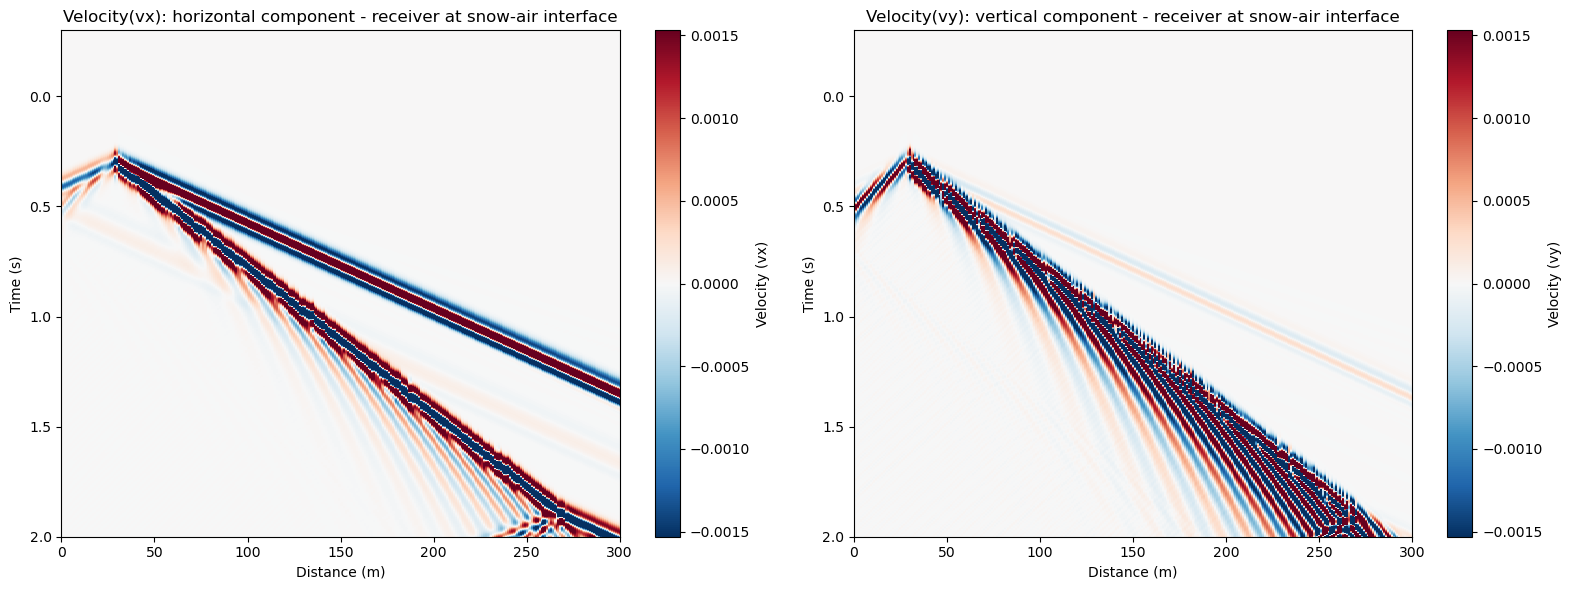

In [53]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 1.5 # This would be at snow-air boundary 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


imshow diagnostics: vx[min,max]=(-8.281e-03, 6.561e-03), vy[min,max]=(-1.521e-02, 1.392e-02), vmax=1.531e-03


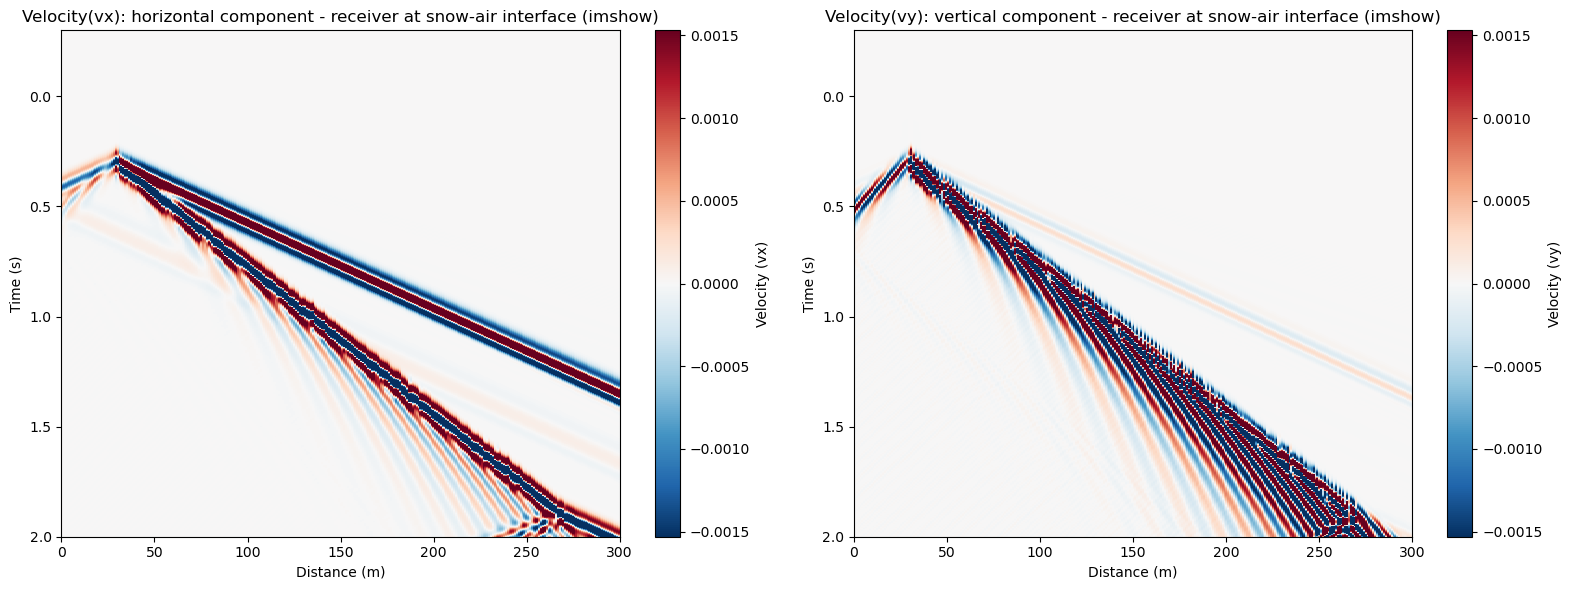

In [54]:
# Plot with imshow and make rendering robust in notebook output.
from IPython.display import display

# Force inline backend in notebook sessions (safe no-op if unavailable).
try:
    plt.switch_backend("module://matplotlib_inline.backend_inline")
except Exception:
    pass

required_vars = ["data_vx", "data_vy", "x_line", "t_vals"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing variables for imshow plot: {missing_vars}. "
        "Run the previous velocity gather cell first."
    )

vx = np.asarray(data_vx, dtype=float)
vy = np.asarray(data_vy, dtype=float)
x = np.asarray(x_line, dtype=float)
t = np.asarray(t_vals, dtype=float)

if vx.ndim != 2 or vy.ndim != 2:
    raise ValueError(f"Expected 2D arrays for data_vx/data_vy, got {vx.ndim}D and {vy.ndim}D.")

# NaN-safe symmetric color scale shared across both panels.
all_abs = np.abs(np.concatenate([vx.ravel(), vy.ravel()]))
vmax = float(np.nanpercentile(all_abs, 95))
if not np.isfinite(vmax) or vmax <= 0.0:
    vmax = 1e-12

extent = [float(np.nanmin(x)), float(np.nanmax(x)), float(np.nanmax(t)), float(np.nanmin(t))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im_vx = axes[0].imshow(
    vx,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="none",
)
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface (imshow)")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

im_vy = axes[1].imshow(
    vy,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="none",
)
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface (imshow)")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()
print(f"imshow diagnostics: vx[min,max]=({np.nanmin(vx):.3e}, {np.nanmax(vx):.3e}), "
      f"vy[min,max]=({np.nanmin(vy):.3e}, {np.nanmax(vy):.3e}), vmax={vmax:.3e}")
display(fig)
plt.close(fig)

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 2.000053711051527
vx shape: (9422, 301)
vy shape: (9422, 301)


/tmp/ipykernel_1869944/3075209493.py:58: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1869944/3075209493.py:80: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


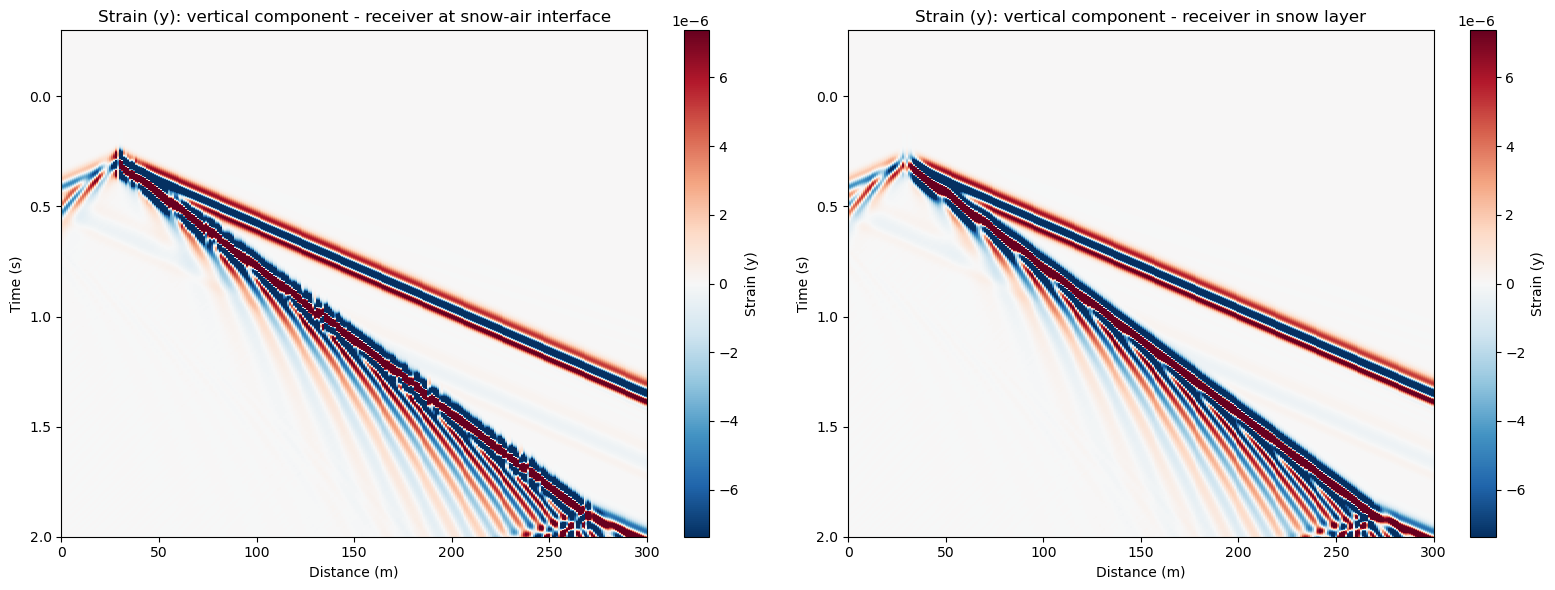

In [55]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 1.5
y_surface_2 = 2.5

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Strain (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Strain (y): vertical component - receiver in snow layer")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


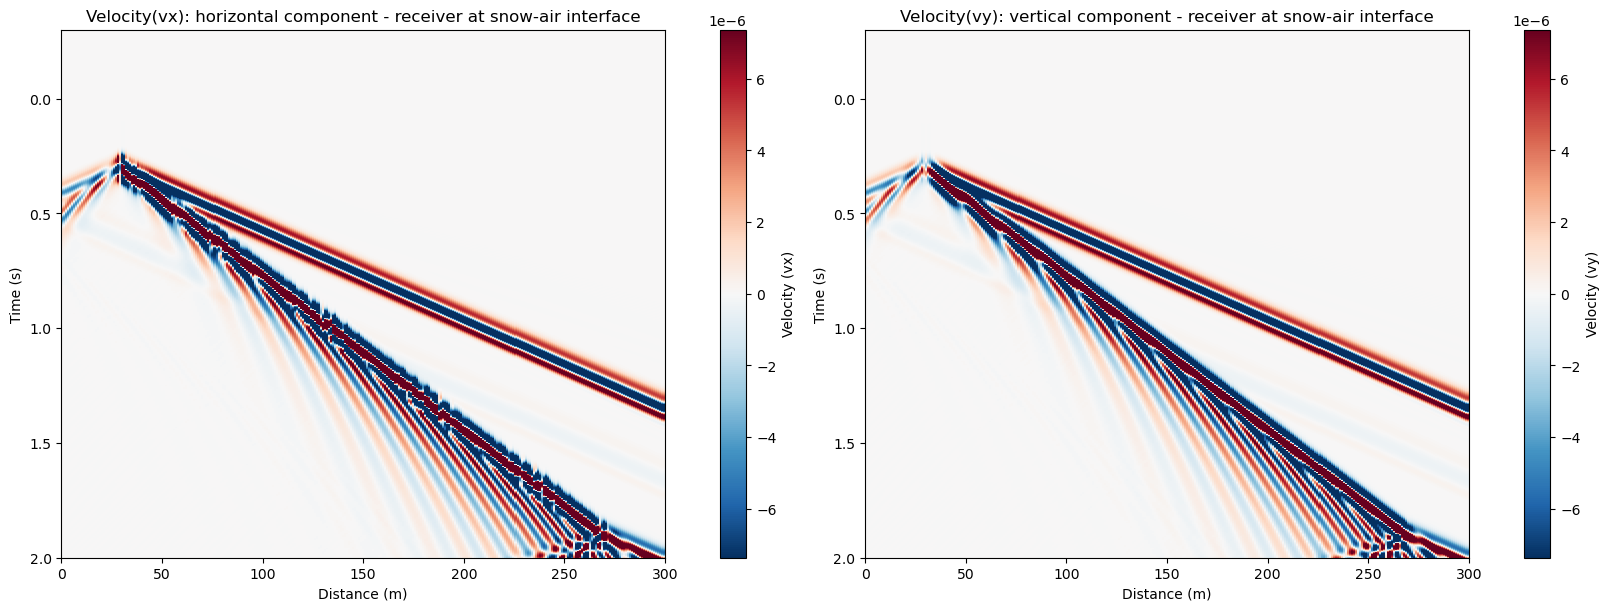

In [56]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# EXACT same scaling for both panels as the pcolormesh version
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

# Same geometry/orientation as pcolormesh + invert_yaxis()
extent = [x_line.min(), x_line.max(), t_vals.max(), t_vals.min()]

im_vx = axes[0].imshow(
    data_vx,
    extent=extent,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=norm,
    interpolation="none", # closest to pcolormesh(shading="none")
    resample=False,
)
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

im_vy = axes[1].imshow(
    data_vy,
    extent=extent,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=norm,
    interpolation="none", # closest to pcolormesh(shading="none")
    resample=False,
)
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

display(fig)
plt.close(fig)



In [57]:
# Build a combined field across all events, matching the waterfall plot logic.
vy_event = vel_2d_layered.isel({c_name: 1})
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)

# Extract raw coordinates and data the same way as static source
# vy_event dims should be (t, y, x) after transpose
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals = vy_event[x_name].values
y_vals = vy_event[y_name].values
t_vals = vy_event[t_name].values
frames_3d = np.asarray(vy_event.values, dtype=np.float64)
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Time subsampling starting from t=0
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 5  # Subsample: take every 5th frame to reduce file size
t_idx = np.arange(t_start_idx, frames_3d.shape[0], N)

# Robust SymLogNorm scaling — same as static source
warmup = max(1, len(frames_3d) // 4)
abs_vals = np.abs(frames_3d[warmup:]).ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]
abs_vals = abs_vals[abs_vals > 1e-14]

if abs_vals.size == 0:
    vmax = 1e-8
    linthresh = 1e-10
else:
    vmax = float(np.percentile(abs_vals, 99.5))
    vmax = max(vmax, 1e-8)
    linthresh = max(float(np.percentile(abs_vals, 70)), vmax * 1e-3, 1e-10)

print("representative_event: combined over all events")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim: {len(t_idx)}")
print(f"vmax={vmax:.3e}, linthresh={linthresh:.3e}")


def run_animation():
    try:
        from matplotlib import colors
        from matplotlib import ticker

        norm = colors.SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax,
            base=10,
        )

        # Avoid mathtext parsing issues in tick labels (especially with SymLog colorbar).
        plt.rcParams["axes.formatter.use_mathtext"] = False

        fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

        im = ax.imshow(
            frames_3d[t_idx[0]],
            extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="upper",
            interpolation="bilinear",
        )

        # Three-layer setup: snow, weak layer, air. Mark the interfaces.
        ax.axhline(1.0, color="black", lw=1.2, linestyle="--", label="snow-weak layer (y=1.0 m)")
        ax.axhline(1.05, color="gray", lw=1.2, linestyle="--", label="weak layer-air (y=1.05 m)")

        ax.set_xlabel("x (m)")
        ax.set_ylabel("Depth (m)")
        ax.set_xlim(x_vals.min(), x_vals.max())
        ax.set_ylim(y_vals.max(), y_vals.min())
        ax.legend(loc="upper right", fontsize=8)
        cbar = plt.colorbar(im, ax=ax, label="Strain", shrink=0.8)
        cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1e}")
        cbar.update_ticks()
        title = ax.set_title(f"Wavefield Strain (all events combined) - t = {t_vals[t_idx[0]]:.4f} s")

        def update(frame_idx):
            ti = t_idx[frame_idx]
            im.set_data(frames_3d[ti])
            title.set_text(f"Wavefield Strain (all events combined) - t = {t_vals[ti]:.4f} s")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(t_idx),
            interval=100,
            blit=False,  # False for Pillow compatibility
        )

        if animation.writers.is_available("ffmpeg"):
            print("Saving with ffmpeg...", flush=True)
            writer = animation.FFMpegWriter(
                fps=15, codec="libx264",
                extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
            )
            output_name = "wavefield_2d_moving_czm.mp4"
        else:
            print("Saving GIF with pillow...", flush=True)
            writer = animation.PillowWriter(fps=10)
            output_name = "wavefield_2d_moving_czm.gif"

        ani.save(
            output_name,
            writer=writer,
            dpi=80,
            progress_callback=lambda i, n: print(
                f"  saving frame {i}/{n}", flush=True
            ) if i % 50 == 0 else None,
        )
        plt.close(fig)
        print(f"Done! Saved as {output_name}", flush=True)
    except Exception as exc:
        import traceback
        print(f"Animation failed: {exc}", flush=True)
        traceback.print_exc()


thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")


representative_event: combined over all events
t range:        -0.300 -> 2.000 s
frames to anim: 1639
vmax=6.573e-03, linthresh=7.496e-05
Animation running in background thread.
Check progress with: thread.is_alive()


Saving GIF with pillow...


  saving frame 0/1639


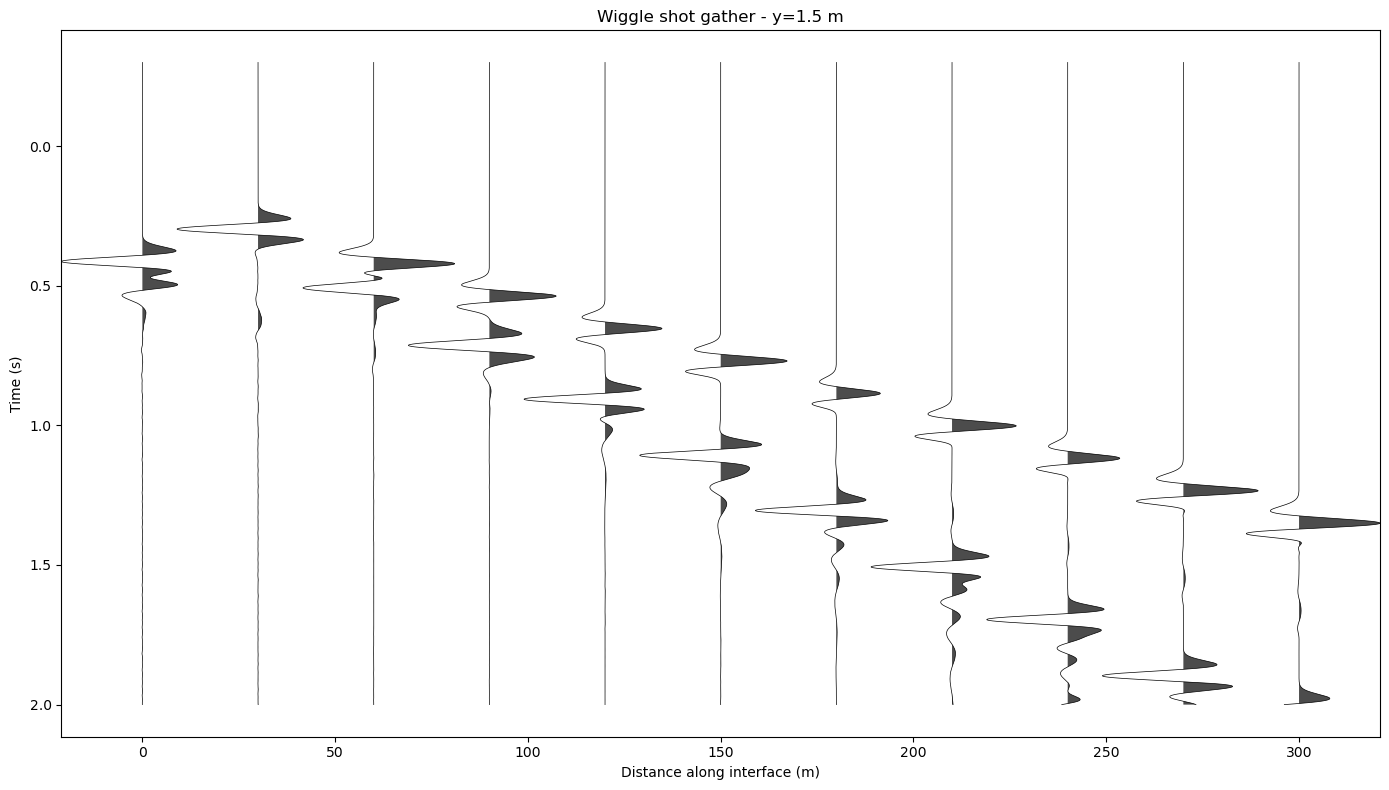

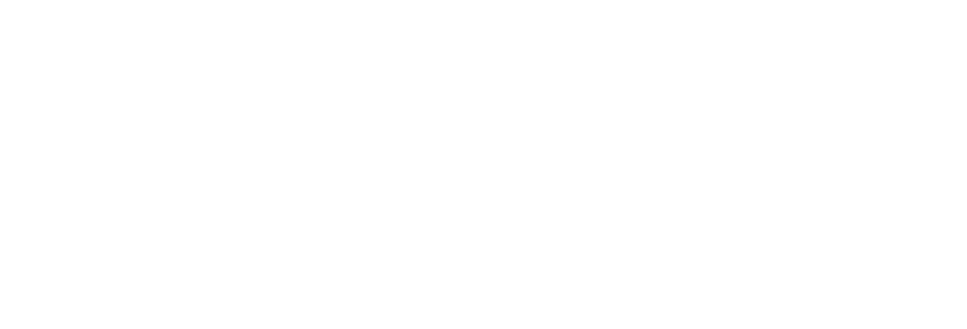

In [58]:
# wiggle plots 
import matplotlib.pyplot as plt
from IPython.display import display

# Wiggle plot form shotgather
sg = sg_vx # component to plot (vx/vy)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x")  # [time, distance]

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values  # shape: [nt, nx]

# Plot settings
trace_step = 30  # plotting  every Nth receiver 
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

 # normalization per trace by its own maximum s that wiggles can be seen 
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:   # skip dead traces
        continue
    tr /= tr_max

    # optional: clip wild amplitudes at early time
    #tr = np.clip(tr, -1, 1)

    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather - y=1.5 m")
plt.tight_layout()
display(fig)
plt.close(fig)


Sampling frequency: 4096.0 Hz
Nyquist frequency:  2048.0 Hz


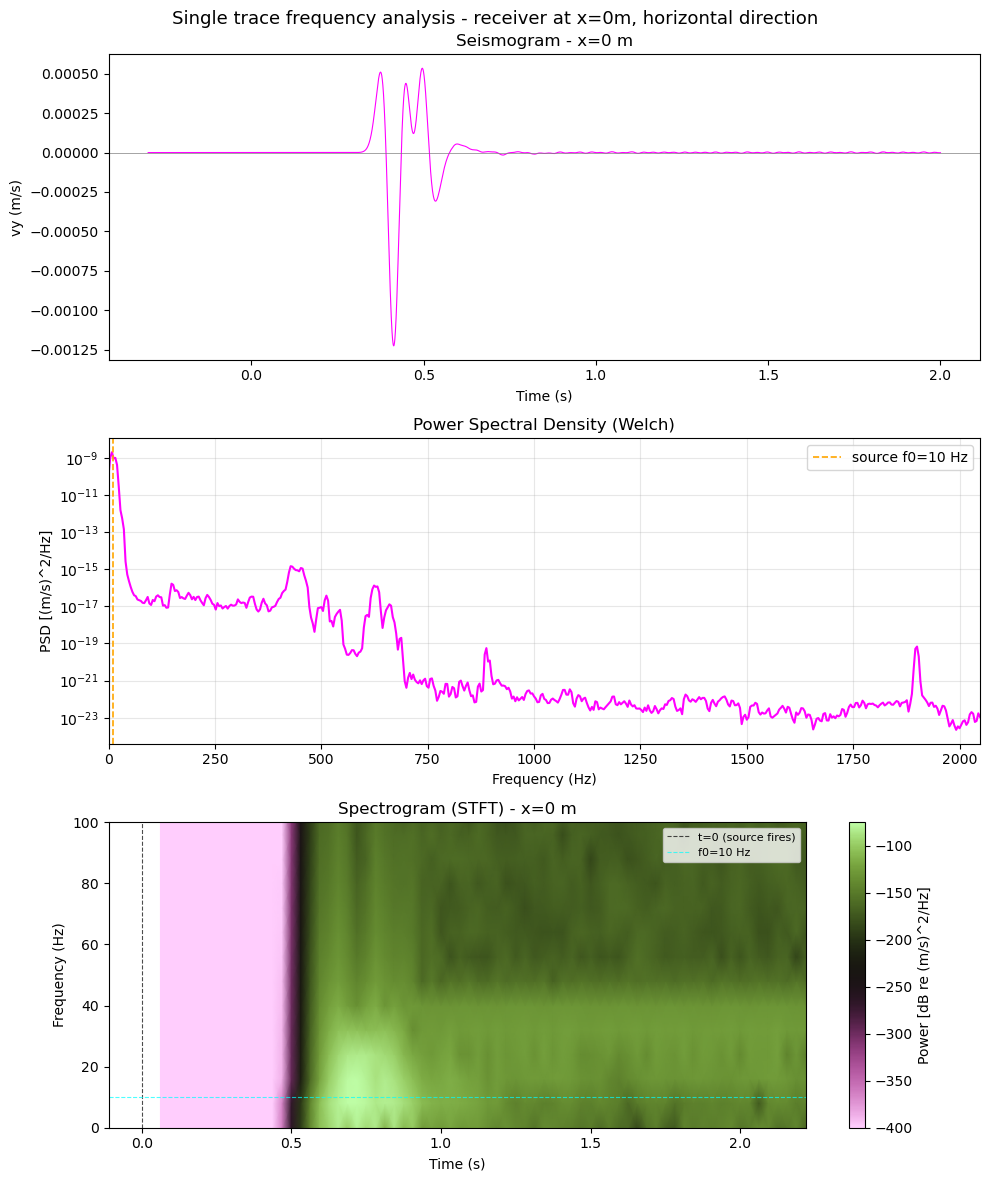

In [59]:

# Extracting trace, picking trace far away from source so that source doesnt dominate
trace = sg_vx.isel({x_name: 0})  # pick receiver at x=150 m (adjust index as needed )
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# PLotting raw seismogram 
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram - x=0 m")
axes[0].axhline(0, color="gray", lw=0.5) 

#  Power Spectral Density (Welch method)
# Welch averages many overlapping windows 
# nperseg controls frequency resolution: longer = finer freq bins
nperseg = min(1024, len(y_vals) // 4)

freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",           # hann window reduces spectral leakage
    scaling="density",       # units ms^2/HZ
)

axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# spectrogram 
# nperseg_stft controls the time/frequency resolution tradeoff:
# longer window --< finer frequency resolution, coarser time resolution
#  shorter window --> finer time resolution, coarser frequency resolution
# aim fabput ~3-5 cycles of  lowest frequency of interest per window --> CHANGE THIS DEPENDING ON WHICH FREQUENCY 
nperseg_stft = min(512, len(y_vals) // 8)

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,   # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)

#log scale for amplitude — seismic signals span many orders of magnitude
Sxx_log = 10 * np.log10(Sxx + 1e-40)   # dB, small floor to avoid log(0)

im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))   # cap at 100 Hz or Nyquist
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis - receiver at x=0m, horizontal direction", fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)

Sampling frequency: 4096.0 Hz
Nyquist frequency:  2048.0 Hz


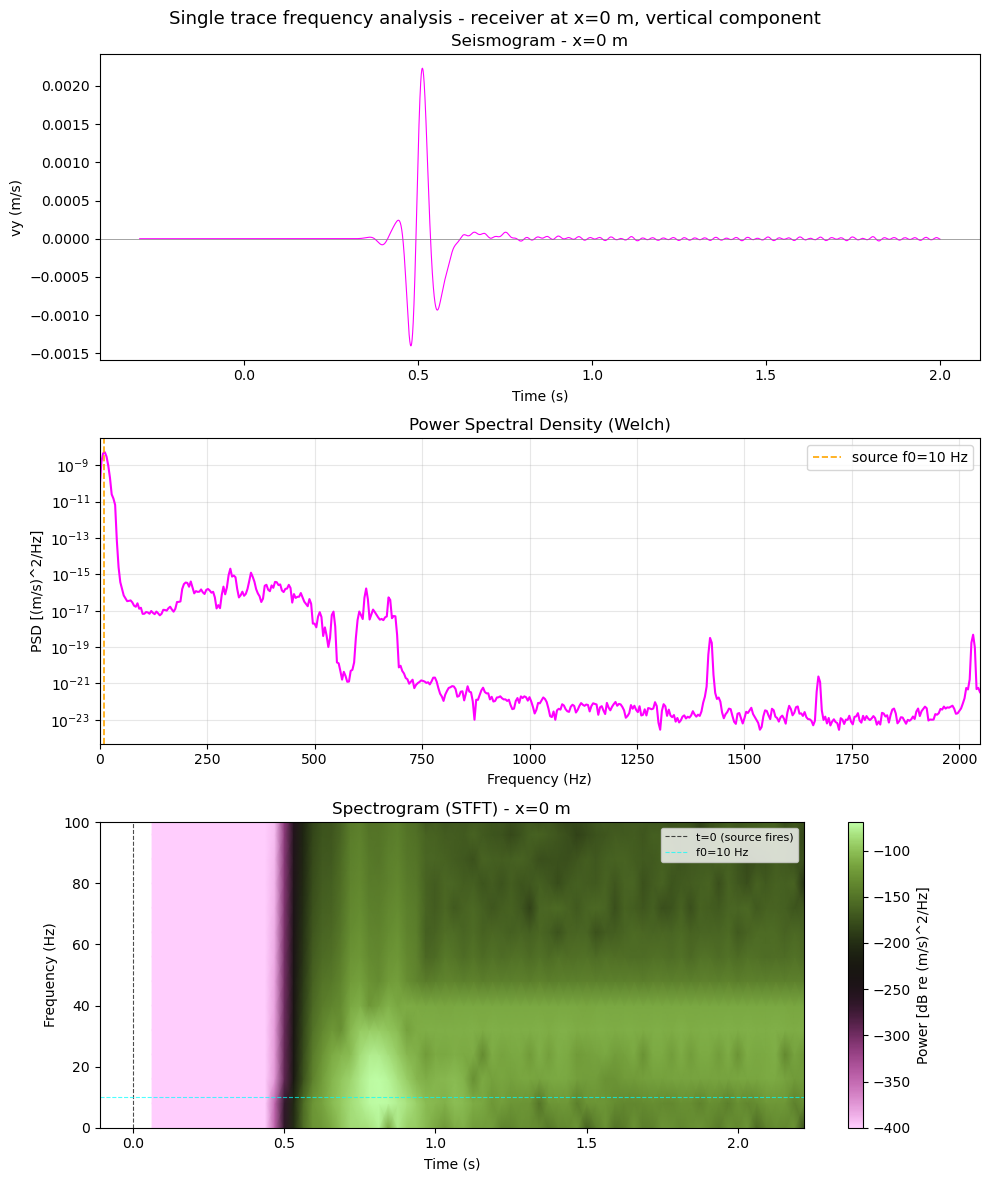

  saving frame 50/1639
  saving frame 100/1639
  saving frame 150/1639
  saving frame 200/1639
  saving frame 250/1639
  saving frame 300/1639
  saving frame 350/1639
  saving frame 400/1639
  saving frame 450/1639
  saving frame 500/1639
  saving frame 550/1639
  saving frame 600/1639
  saving frame 650/1639
  saving frame 700/1639
  saving frame 750/1639
  saving frame 800/1639
  saving frame 850/1639
  saving frame 900/1639
  saving frame 950/1639
  saving frame 1000/1639
  saving frame 1050/1639
  saving frame 1100/1639
  saving frame 1150/1639
  saving frame 1200/1639
  saving frame 1250/1639
  saving frame 1300/1639
  saving frame 1350/1639
  saving frame 1400/1639
  saving frame 1450/1639
  saving frame 1500/1639
  saving frame 1550/1639
  saving frame 1600/1639
Done! Saved as wavefield_2d_moving_czm.gif


In [ ]:

# Extracting trace, picking trace far away from source so that source doesnt dominate
trace = sg_vy.isel({x_name: 0})  # pick receiver at x=150 m (adjust index as needed )
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# PLotting raw seismogram 
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram - x=0 m")
axes[0].axhline(0, color="gray", lw=0.5) 

#  Power Spectral Density (Welch method)
# Welch averages many overlapping windows 
# nperseg controls frequency resolution: longer = finer freq bins
nperseg = min(1024, len(y_vals) // 4)

freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",  # hann window reduces spectral leakage
    scaling="density", # units ms^2/HZ
)

axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# spectrogram 
# nperseg_stft controls the time/frequency resolution tradeoff:
# longer window --< finer frequency resolution, coarser time resolution
#  shorter window --> finer time resolution, coarser frequency resolution
# aim fabput ~3-5 cycles of  lowest frequency of interest per window --> CHANGE THIS DEPENDING ON WHICH FREQUENCY 
nperseg_stft = min(512, len(y_vals) // 8)

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,   # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)

#log scale for amplitude — seismic signals span many orders of magnitude
Sxx_log = 10 * np.log10(Sxx + 1e-40)   # dB, small floor to avoid log(0)

im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))   # cap at 100 Hz or Nyquist
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis - receiver at x=0 m, vertical component", fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)